# 📊 Probe Feature EDA — Segment-Level Analysis

This notebook performs exploratory data analysis on `feat_probe.parquet`,
which is already **snapped to road segments** and **binned by time of day**.

Each row = one road segment (`segment_id`) with aggregated probe statistics.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

FEAT_PATH = '../../data/processed/features/feat_probe.parquet'
TIME_BINS = ['morning_peak', 'daytime', 'evening_peak', 'night', 'late_night']
LABELS    = ['Morning Peak', 'Daytime', 'Evening Peak', 'Night', 'Late Night']

df = pd.read_parquet(FEAT_PATH)
print(f'Loaded {len(df):,} segments')
print(f'Columns: {list(df.columns)}')
df.head()

Loaded 277,069 segments
Columns: ['segment_id', 'probe_count_daytime', 'probe_count_evening_peak', 'probe_count_late_night', 'probe_count_morning_peak', 'probe_count_night', 'speed_mean_daytime', 'speed_mean_evening_peak', 'speed_mean_late_night', 'speed_mean_morning_peak', 'speed_mean_night', 'pct_below_20kmh_daytime', 'pct_below_20kmh_evening_peak', 'pct_below_20kmh_late_night', 'pct_below_20kmh_morning_peak', 'pct_below_20kmh_night', 'probe_count', 'speed_mean']


,segment_id,probe_count_daytime,probe_count_evening_peak,probe_count_late_night,probe_count_morning_peak,probe_count_night,speed_mean_daytime,speed_mean_evening_peak,speed_mean_late_night,speed_mean_morning_peak,speed_mean_night,pct_below_20kmh_daytime,pct_below_20kmh_evening_peak,pct_below_20kmh_late_night,pct_below_20kmh_morning_peak,pct_below_20kmh_night,probe_count,speed_mean
0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
1,1,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2,2,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,3,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,4,3,2,2,2,3,8.0,11.5,5.5,8.5,9.67,100.0,100.0,100.0,100.0,100.0,12,8.67


## Step 1: Overview — Global Probe Statistics per Segment

=== Global Probe Statistics ===
       probe_count  speed_mean
count    277069.00   263457.00
mean       4864.43       20.76
std       14447.43       15.33
min           0.00        1.00
25%          24.00       10.85
50%         158.00       15.42
75%        1567.00       25.16
max      390478.00      199.00


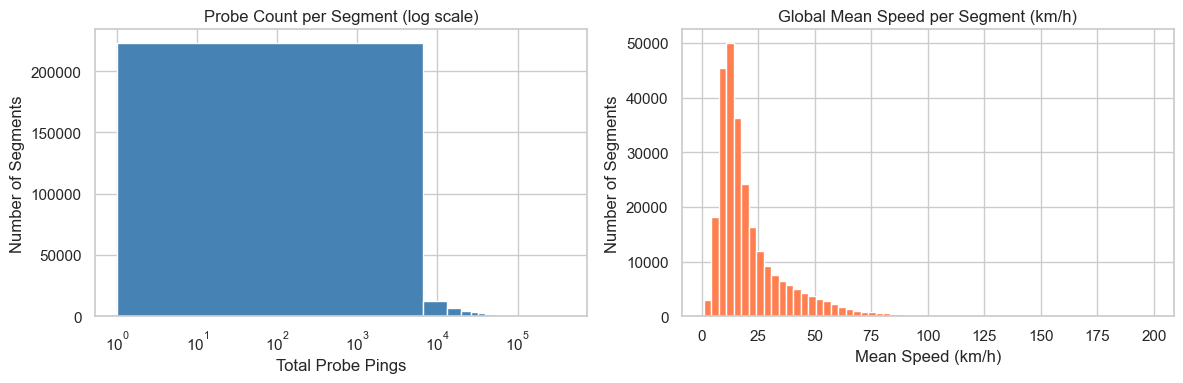


Segments with ZERO probe pings: 4.9%


In [8]:
print('=== Global Probe Statistics ===')
print(df[['probe_count', 'speed_mean']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Probe count distribution (log scale)
counts = df['probe_count']
axes[0].hist(counts[counts > 0], bins=60, color='steelblue', edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_title('Probe Count per Segment (log scale)')
axes[0].set_xlabel('Total Probe Pings')
axes[0].set_ylabel('Number of Segments')

# Global mean speed distribution
speeds = df['speed_mean'].dropna()
axes[1].hist(speeds, bins=60, color='coral', edgecolor='white')
axes[1].set_title('Global Mean Speed per Segment (km/h)')
axes[1].set_xlabel('Mean Speed (km/h)')
axes[1].set_ylabel('Number of Segments')

plt.tight_layout()
plt.show()

zero_pct = (df['probe_count'] == 0).mean() * 100
print(f'\nSegments with ZERO probe pings: {zero_pct:.1f}%')

## Step 2: Coverage — % of Segments with Data per Time Bin

    Time Bin  Coverage %
Morning Peak   85.217401
     Daytime   92.458557
Evening Peak   89.960984
       Night   85.811837
  Late Night   81.896928


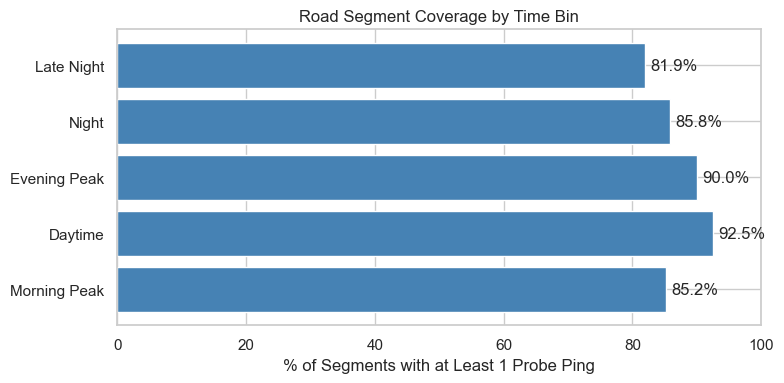

In [9]:
total = len(df)

coverage = []
for tbin in TIME_BINS:
    col = f'probe_count_{tbin}'
    covered = (df[col] > 0).sum()
    coverage.append({'Time Bin': tbin.replace('_', ' ').title(), 'Coverage %': covered / total * 100})

cov_df = pd.DataFrame(coverage)
print(cov_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cov_df['Time Bin'], cov_df['Coverage %'], color='steelblue')
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_xlim(0, 100)
ax.set_xlabel('% of Segments with at Least 1 Probe Ping')
ax.set_title('Road Segment Coverage by Time Bin')
plt.tight_layout()
plt.show()

## Step 3: Speed — Mean Speed Distribution per Time Bin

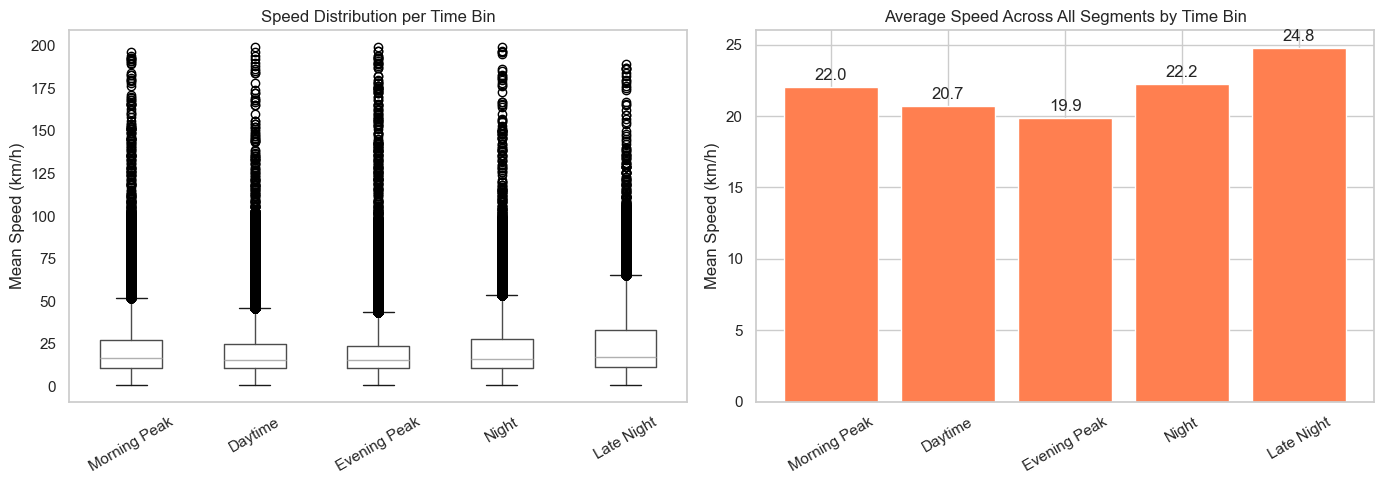

=== Speed Stats per Time Bin (km/h) ===
       Morning Peak    Daytime  Evening Peak      Night  Late Night
count     236111.00  256174.00     249254.00  237758.00   226911.00
mean          22.03      20.69         19.88      22.24       24.77
std           16.68      15.24         14.49      16.98       19.57
min            1.00       1.00          1.00       1.00        1.00
25%           11.00      10.86         10.67      10.90       11.17
50%           16.50      15.56         15.24      16.15       17.38
75%           27.44      24.95         23.93      28.00       32.92
max          196.00     199.00        199.00     199.00      189.00


In [10]:
speed_cols = [f'speed_mean_{t}' for t in TIME_BINS]
speed_data = df[speed_cols].copy()
speed_data.columns = LABELS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
speed_data.boxplot(ax=axes[0], grid=False)
axes[0].set_title('Speed Distribution per Time Bin')
axes[0].set_ylabel('Mean Speed (km/h)')
axes[0].tick_params(axis='x', rotation=30)

# Mean speed summary bar chart
means = speed_data.mean()
bars = axes[1].bar(means.index, means.values, color='coral')
axes[1].bar_label(bars, fmt='%.1f', padding=3)
axes[1].set_title('Average Speed Across All Segments by Time Bin')
axes[1].set_ylabel('Mean Speed (km/h)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('=== Speed Stats per Time Bin (km/h) ===')
print(speed_data.describe().round(2))

## Step 4: Congestion — % Below 20 km/h per Time Bin

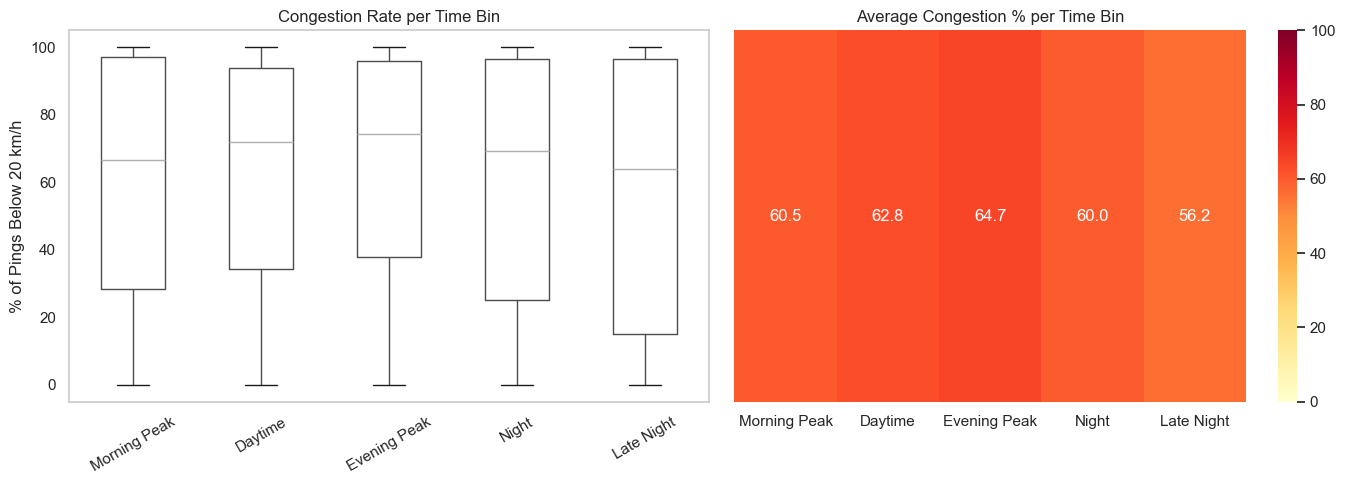

=== Congestion % Stats per Time Bin ===
       Morning Peak    Daytime  Evening Peak      Night  Late Night
count     236111.00  256174.00     249254.00  237758.00   226911.00
mean          60.47      62.81         64.68      60.01       56.16
std           35.42      33.60         33.17      36.43       38.22
min            0.00       0.00          0.00       0.00        0.00
25%           28.38      34.29         37.84      25.00       14.92
50%           66.67      72.00         74.29      69.23       63.83
75%           97.14      93.96         96.08      96.41       96.43
max          100.00     100.00        100.00     100.00      100.00


In [11]:
cong_cols = [f'pct_below_20kmh_{t}' for t in TIME_BINS]
cong_data = df[cong_cols].copy()
cong_data.columns = LABELS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
cong_data.boxplot(ax=axes[0], grid=False)
axes[0].set_title('Congestion Rate per Time Bin')
axes[0].set_ylabel('% of Pings Below 20 km/h')
axes[0].tick_params(axis='x', rotation=30)

# Heatmap: mean congestion per time bin
mean_cong = cong_data.mean().to_frame(name='Avg Congestion %').T
sns.heatmap(mean_cong, annot=True, fmt='.1f', cmap='YlOrRd',
            vmin=0, vmax=100, ax=axes[1])
axes[1].set_title('Average Congestion % per Time Bin')
axes[1].set_yticklabels([])

plt.tight_layout()
plt.show()

print('=== Congestion % Stats per Time Bin ===')
print(cong_data.describe().round(2))

## Step 5: Sparsity — Probe Count Heatmap per Time Bin

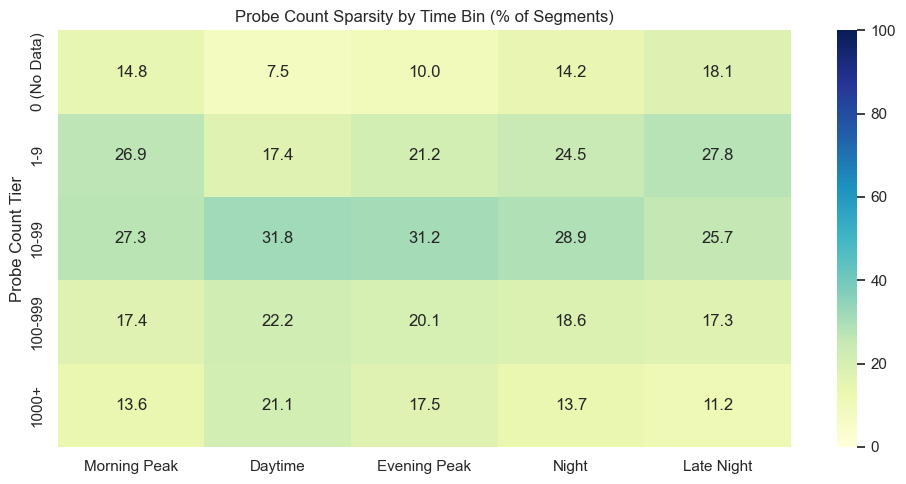

=== Probe Count Stats per Time Bin ===
       Morning Peak   Daytime  Evening Peak     Night  Late Night
count      277069.0  277069.0      277069.0  277069.0    277069.0
mean          605.0    1909.0        1077.0     730.0       545.0
std          1765.0    5687.0        3131.0    2336.0      1923.0
min             0.0       0.0           0.0       0.0         0.0
25%             2.0      10.0           6.0       3.0         1.0
50%            18.0      60.0          37.0      22.0        13.0
75%           201.0     596.0         363.0     222.0       149.0
max         55317.0  153074.0       71107.0   60727.0     70509.0


In [12]:
count_cols = [f'probe_count_{t}' for t in TIME_BINS]
count_data = df[count_cols].copy()
count_data.columns = LABELS

# Bucketize probe count into sparsity tiers
def sparsity_tier(x):
    if x == 0:   return '0 (No Data)'
    if x < 10:   return '1-9'
    if x < 100:  return '10-99'
    if x < 1000: return '100-999'
    return '1000+'

tier_order = ['0 (No Data)', '1-9', '10-99', '100-999', '1000+']

tier_pcts = {}
for col_label in LABELS:
    tiers = count_data[col_label].apply(sparsity_tier)
    pcts = tiers.value_counts(normalize=True).reindex(tier_order, fill_value=0) * 100
    tier_pcts[col_label] = pcts

tier_df = pd.DataFrame(tier_pcts)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(tier_df, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100, ax=ax)
ax.set_title('Probe Count Sparsity by Time Bin (% of Segments)')
ax.set_ylabel('Probe Count Tier')
plt.tight_layout()
plt.show()

print('=== Probe Count Stats per Time Bin ===')
print(count_data.describe().round(0))